Reproduction of  "Grokking modular arithmetic" by Andrey Gromov 

In [48]:
#!git clone https://github.com/naxilef/Grokking-Project.git
#%cd /content/Grokking-Project

In [49]:
import math
import json
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from models.modular_mlp import ModularMLP
from data.modular_arith import generate_all_pairs, encode_pair, modular_addition, split_dataset, make_modular_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [50]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def weight_norms(model):
    return (
        model.W1.weight.detach().norm().item(),
        model.W2.weight.detach().norm().item(),
    )

def grad_norms(model):
    g1 = model.W1.weight.grad.norm().item() if model.W1.weight.grad is not None else 0.0
    g2 = model.W2.weight.grad.norm().item() if model.W2.weight.grad is not None else 0.0
    return g1, g2

def effective_rank_from_singular_values(s, eps=1e-12):
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / s.sum()
    entropy = -(p * torch.log(p + eps)).sum()
    return torch.exp(entropy).item() 

@torch.no_grad()
def effective_rank_w1(model):
    w1 = model.W1.weight.detach()
    s = torch.linalg.svdvals(w1)
    return effective_rank_from_singular_values(s)

@torch.no_grad()
def effective_rank_hidden(model, x):
    h = model.hidden(x)
    h = h - h.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(h)
    return effective_rank_from_singular_values(s)

@torch.no_grad()
def get_W1_singular_values(model):
    w1 = model.W1.weight.detach()
    s = torch.linalg.svdvals(w1).detach().cpu().numpy()
    return s

@torch.no_grad()
def get_w1_eigenvalues(model):
    W1 = model.W1.weight.detach()
    eigvals = torch.linalg.svdvals(W1) ** 2
    return eigvals.cpu().numpy()

@torch.no_grad()
def evaluate(model, loader, p, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x,y in loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        y_onehot = F.one_hot(y, num_classes=p).float()
        loss = F.mse_loss(outputs, y_onehot)

        total_loss += loss.item() * x.size(0)
        total_correct += (torch.argmax(outputs, dim=1) == y).sum().item()
        total_count += x.size(0)

    return {
        "loss": total_loss / total_count,
        "acc": total_correct / total_count,
    }

def train(
    p=97,
    hidden_dim=512,
    alpha=0.49,
    seed=0,
    activation="quadratic",
    lr=1e-2,
    epochs=200_000,
    eval_every=100,
    optimizer_name="sgd",
    weight_decay=0.0,
):
    torch.manual_seed(seed)

    arith_tensor = make_modular_dataset(p, modular_addition)

    train_dataset, test_dataset = split_dataset(arith_tensor.x, arith_tensor.y, alpha=alpha, seed=seed)

    train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

    probe_size = min(1000, len(arith_tensor.x))

    probe_generator = torch.Generator().manual_seed(seed + 999)
    probe_idx = torch.randperm(len(arith_tensor.x), generator=probe_generator)[:probe_size]

    probe_x = arith_tensor.x[probe_idx].to(device)
    
    model = ModularMLP(p=p, hidden_dim=hidden_dim, activation=activation).to(device)

    if optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
    elif optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adamw'")

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],

        "w1_norm": [],
        "w2_norm": [],
        "g1_norm": [],
        "g2_norm": [],

        "effective_rank_w1": [],
        "effective_rank_hidden": [],

        "w1_spectrum": [],
    }

    svd_history = {
        "epoch": [],
        "singular_values": [],
    }

    eigvals = {}

    for epoch in range(1, epochs + 1):
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            y_onehot = F.one_hot(y_batch, num_classes=p).float()
            loss = F.mse_loss(outputs, y_onehot)

            optimizer.zero_grad()
            loss.backward()

            g1, g2 = grad_norms(model)
            optimizer.step()

        if epoch == 1 or epoch % eval_every == 0:
            train_metrics = evaluate(model, train_loader, p, device)
            test_metrics = evaluate(model, test_loader, p, device)
            w1, w2 = weight_norms(model)

            erw1 = effective_rank_w1(model)
            erh = effective_rank_hidden(model, probe_x)

            w1_eigen = get_w1_eigenvalues(model)
            eigvals[epoch] = w1_eigen

            history["epoch"].append(epoch)
            history["train_loss"].append(train_metrics["loss"])
            history["test_loss"].append(test_metrics["loss"])
            history["train_acc"].append(train_metrics["acc"])
            history["test_acc"].append(test_metrics["acc"])
            history["w1_norm"].append(w1)
            history["w2_norm"].append(w2)
            history["g1_norm"].append(g1)
            history["g2_norm"].append(g2)

            history["effective_rank_w1"].append(erw1)
            history["effective_rank_hidden"].append(erh)
            history["w1_spectrum"].append(w1_eigen)

            svd_history["epoch"].append(epoch)
            svd_history["singular_values"].append(get_W1_singular_values(model))
            
            print(
                f"Epoch {epoch:>7d} | "
                f"train_loss={train_metrics['loss']:.6f} | "
                f"test_loss={test_metrics['loss']:.6f} | "
                f"train_acc={100 * train_metrics['acc']:.2f}% | "
                f"test_acc={100 * test_metrics['acc']:.2f}% | "
                f"||W1||={w1:.4f} | ||W2||={w2:.4f}"
            )

    return model, history, svd_history, eigvals


In [51]:
RUNS_DIR = Path("runs")
RUNS_DIR.mkdir(exist_ok=True)

def plot_losses(history, r=None):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train")
    plt.plot(history["epoch"], history["test_loss"], label="test")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Train/Test Loss")
    plt.legend()
    plt.grid(True)
    if r is not None:
        plt.savefig(r / "losses.png", dpi=300, bbox_inches="tight")
    plt.show()

def plot_accuracy(history, r=None):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], [100 * x for x in history["train_acc"]], label="train")
    plt.plot(history["epoch"], [100 * x for x in history["test_acc"]], label="test")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title("Train/Test Accuracy")
    plt.legend()
    plt.grid(True)
    if r is not None:
        plt.savefig(r / "accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

def plot_weight_norms(history, r=None):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["w1_norm"], label="||W1||")
    plt.plot(history["epoch"], history["w2_norm"], label="||W2||")
    plt.xlabel("epoch")
    plt.ylabel("norm")
    plt.title("Weight Norms")
    plt.legend()
    plt.grid(True)
    if r is not None:
        plt.savefig(r / "weight-norms.png", dpi=300, bbox_inches="tight")
    plt.show()

def plot_gradient_norms(history, r=None):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["g1_norm"], label="||grad W1||")
    plt.plot(history["epoch"], history["g2_norm"], label="||grad W2||")
    plt.xlabel("epoch")
    plt.ylabel("norm")
    plt.title("Gradient Norms")
    plt.legend()
    plt.grid(True)
    if r is not None:
        plt.savefig(r / "gradient-norms.png", dpi=300, bbox_inches="tight")
    plt.show()

def get_next_run_dir(base_dir=RUNS_DIR):
    existing_nums = []
    
    for item in base_dir.iterdir():
        if item.is_dir() and item.name.isdigit():
            existing_nums.append(int(item.name))
    
    next_num = 1 if not existing_nums else max(existing_nums) + 1
    run_dir = base_dir / str(next_num)
    run_dir.mkdir(exist_ok=True)
    return run_dir

def save_all_plots(history, config, r=None):
    
    config_path = Path(r) / "config.txt"
    with open(config_path, "w", encoding="utf-8") as f:
        for key, value in config.items():
            f.write(f"{key}: {value}\n")

    plot_losses(history, r)
    plot_accuracy(history, r)
    plot_weight_norms(history, r)
    plot_gradient_norms(history, r)
    
    print(f"Plots saved in: {r}")


In [52]:
config = {
    "p": 97,
    "hidden_dim": 512,
    "alpha": 0.49,
    "seed": 21,
    "activation": "quadratic",
    "lr": 1e-2,
    "epochs": 3000,
    "eval_every": 100,
    "optimizer_name": "adamW",
    "weight_decay": 0.01,
}
print(config)

{'p': 97, 'hidden_dim': 512, 'alpha': 0.49, 'seed': 21, 'activation': 'quadratic', 'lr': 0.01, 'epochs': 3000, 'eval_every': 100, 'optimizer_name': 'adamW', 'weight_decay': 0.01}


In [53]:
model, history, svd_history, eigvals = train(**config)

Epoch       1 | train_loss=0.010309 | test_loss=0.010309 | train_acc=1.02% | test_acc=1.02% | ||W1||=313.1873 | ||W2||=221.5883
Epoch     100 | train_loss=0.010250 | test_loss=0.010260 | train_acc=2.75% | test_acc=0.65% | ||W1||=322.8475 | ||W2||=227.9648
Epoch     200 | train_loss=0.010205 | test_loss=0.010228 | train_acc=5.29% | test_acc=0.35% | ||W1||=349.0567 | ||W2||=244.2887
Epoch     300 | train_loss=0.010178 | test_loss=0.010218 | train_acc=7.94% | test_acc=0.25% | ||W1||=373.2965 | ||W2||=259.7945
Epoch     400 | train_loss=0.010161 | test_loss=0.010221 | train_acc=11.69% | test_acc=0.21% | ||W1||=389.6142 | ||W2||=270.5681
Epoch     500 | train_loss=0.010144 | test_loss=0.010227 | train_acc=18.44% | test_acc=0.13% | ||W1||=403.9726 | ||W2||=280.3829
Epoch     600 | train_loss=0.010121 | test_loss=0.010236 | train_acc=29.15% | test_acc=0.06% | ||W1||=421.5830 | ||W2||=292.6612
Epoch     700 | train_loss=0.010090 | test_loss=0.010248 | train_acc=42.56% | test_acc=0.00% | ||W1||

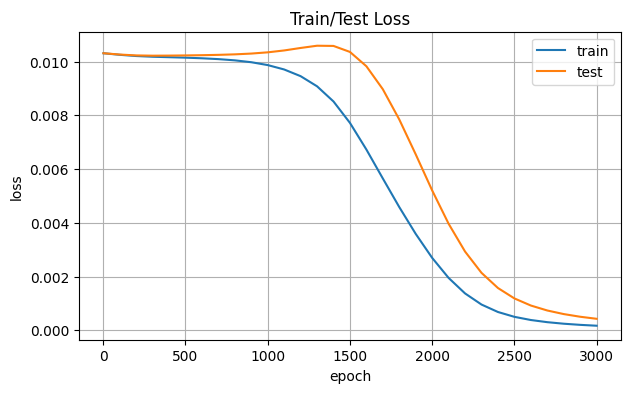

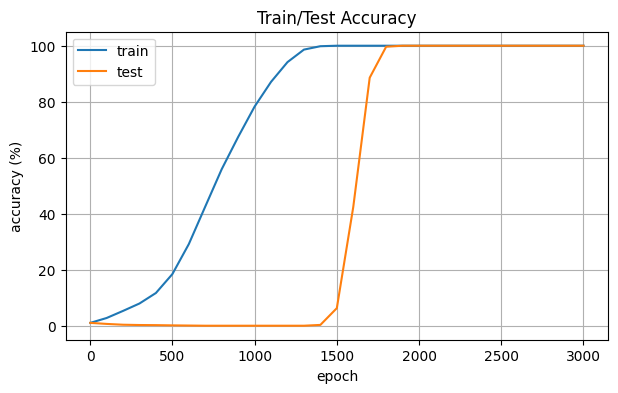

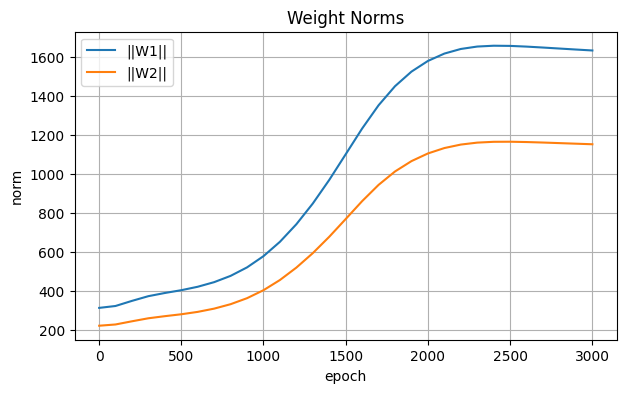

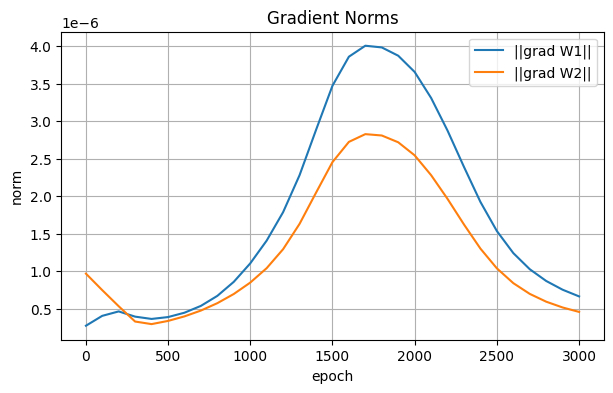

Plots saved in: runs\6


In [54]:
RUNS_NUMBER = get_next_run_dir()

save_all_plots(history, config, RUNS_NUMBER)

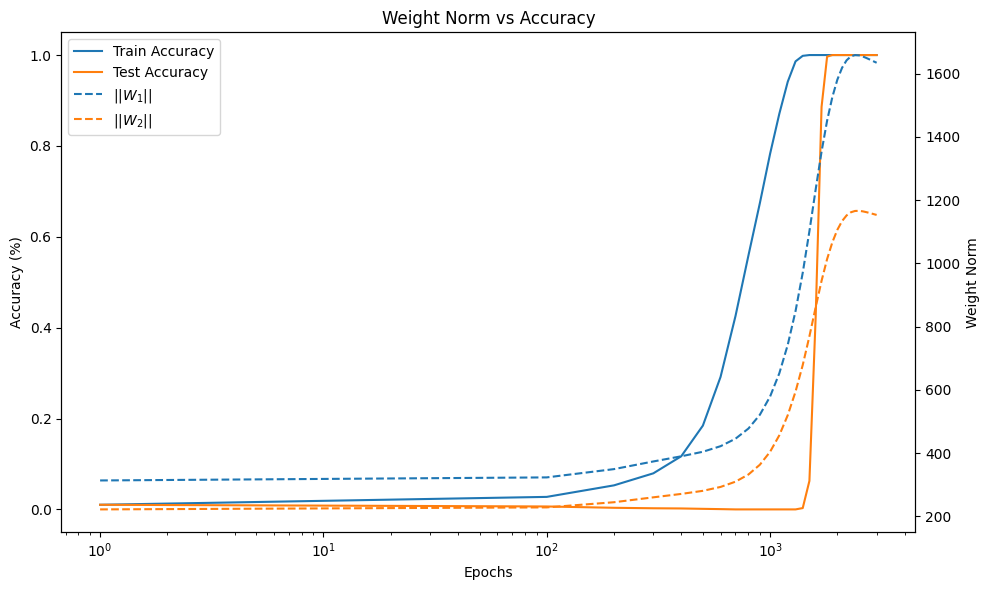

In [55]:
import numpy as np
def plot_weight_norm_vs_accuracy(history, log_x=True, r=None):
   
    x = np.array(history["epoch"])
    x_label = "Epochs"
   

    train_acc = np.array(history["train_acc"])
    test_acc  = np.array(history["test_acc"])
    w1_norm   = np.array(history["w1_norm"])
    w2_norm   = np.array(history["w2_norm"])

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # accuracy curves
    ax1.plot(x, train_acc, label="Train Accuracy")
    ax1.plot(x, test_acc, label="Test Accuracy")

    # norm curves
    ax2.plot(x, w1_norm, linestyle="--", label=r"$||W_1||$")
    ax2.plot(x, w2_norm, linestyle="--", label=r"$||W_2||$")

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Accuracy (%)")
    ax2.set_ylabel("Weight Norm")

    if log_x:
        ax1.set_xscale("log")
        ax2.set_xscale("log")

    # combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title("Weight Norm vs Accuracy")
    plt.tight_layout()
    if r is not None:
        plt.savefig(r / "weight-norms-vs-accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_weight_norm_vs_accuracy(history=history, r=RUNS_NUMBER)

In [56]:
def plot_3d_svd_histogram(svd_history, bins=30, figsize=(12, 8), max_epochs_shown=None, r=None):
    epochs = svd_history["epoch"]
    spectra = svd_history["singular_values"]

    if max_epochs_shown is not None:
        epochs = epochs[:max_epochs_shown]
        spectra = spectra[:max_epochs_shown]

    # global bin edges across all epochs
    all_sv = np.concatenate(spectra)
    hist_range = (all_sv.min(), all_sv.max())
    bin_edges = np.histogram_bin_edges(all_sv, bins=bins, range=hist_range)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    dx = (bin_edges[1] - bin_edges[0]) * 0.9

    if len(epochs) > 1:
        dy = max(1, np.min(np.diff(epochs))) * 0.8
    else:
        dy = 1.0

    for epoch, svals in zip(epochs, spectra):
        hist, _ = np.histogram(svals, bins=bin_edges)

        xs = bin_edges[:-1]
        ys = np.full_like(xs, epoch, dtype=float)
        zs = np.zeros_like(xs, dtype=float)

        ax.bar3d(xs, ys, zs, dx, dy, hist, alpha=0.8, shade=True)

    ax.set_title(r"3D histogram of singular values of $W_1$")
    ax.set_xlabel("Singular value")
    ax.set_ylabel("Epoch")
    ax.set_zlabel("Count")

    plt.tight_layout()

    if r is not None:
        plt.savefig(r / "w1-3d-svd-histogram.png", dpi=300, bbox_inches="tight")

    plt.show()

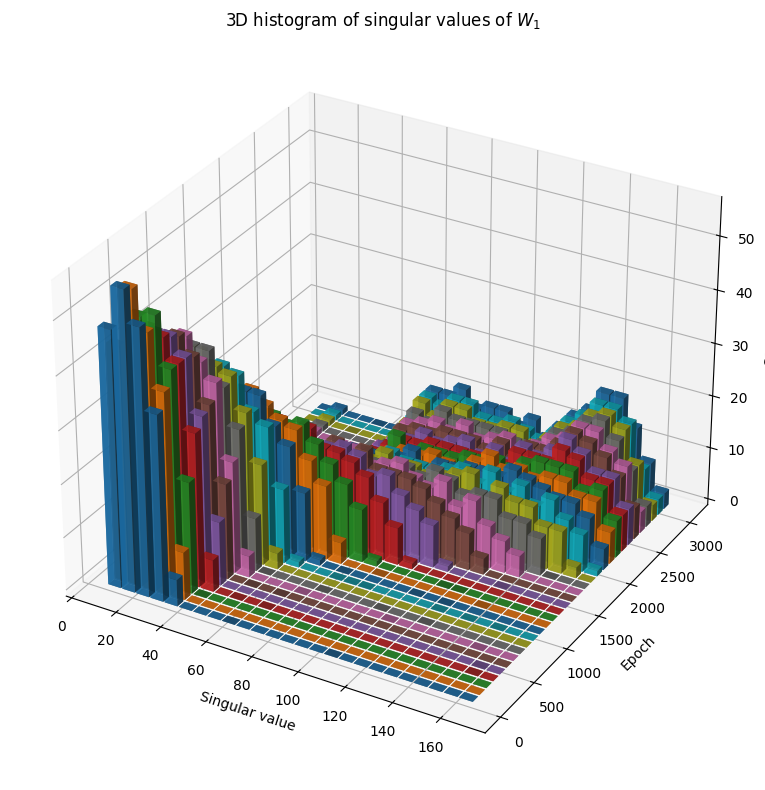

In [57]:
plot_3d_svd_histogram(svd_history, bins=25, r=RUNS_NUMBER)

In [58]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(6, 4))
bins = 15
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Frequency")
title = ax.set_title("")  # we'll update this per frame

# Plot once so we have the Patch objects to update later
n, _, bars = ax.hist(eigvals[1], bins=bins, color="steelblue", edgecolor="white")

def update(frame: int):
    """Redraw the histogram for frame `frame` in place."""
    # Update bar heights without re‑creating the patches
    # n[i] becomes the new height of bars[i]
    epoch = list(eigvals.keys())[frame]
    n, _ = np.histogram(eigvals[epoch], bins=bins)
    for count, rect in zip(n, bars):
        rect.set_height(count)

    title.set_text(f"Epoch #{epoch:d}")
    return (*bars, title) # artists to re‑draw

plt.close("all")

# Build the animation
anim = FuncAnimation(
    fig,
    update,
    frames=len(eigvals),
    interval=100, # number of ms between frames
    # blit=True, # only redraw the artists we return -> smoother
    repeat=True,
)

plt.show()

# Jupyter inline JS animation (no external tools needed)
from IPython.display import HTML
HTML(anim.to_jshtml())


In [ ]:
def plot_w1_effective_rank(history, save_path=None):
    plt.figure(figsize=(7, 4))

    plt.plot(history["epoch"], history["effective_rank_w1"], label="W1 effective rank")

    plt.xlabel("Epoch")
    plt.ylabel("Effective rank")
    plt.title("Effective Rank of W1 by Epoch")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

def plot_hidden_effective_rank(history, save_path=None):
    plt.figure(figsize=(7, 4))

    plt.plot(history["epoch"], history["effective_rank_hidden"], label="Hidden effective rank")

    plt.xlabel("Epoch")
    plt.ylabel("Effective rank")
    plt.title("Effective Rank of Hidden Layer by Epoch")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

def plot_hidden_effective_rank_and_test_accuracy(history, save_path=None):
    fig, ax1 = plt.subplots(figsize=(8, 4))

    ax1.plot(
        history["epoch"],
        history["effective_rank_hidden"],
        label="Hidden effective rank",
    )
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Hidden effective rank")
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(
        history["epoch"],
        [100 * acc for acc in history["test_acc"]],
        linestyle="--",
        label="Test accuracy",
    )
    ax2.set_ylabel("Test accuracy (%)")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    plt.title("Hidden Effective Rank and Test Accuracy by Epoch")

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

plot_w1_effective_rank(history, RUNS_NUMBER)
plot_hidden_effective_rank(history, RUNS_NUMBER)
plot_hidden_effective_rank_and_test_accuracy(history, RUNS_NUMBER)